# Niveau 3 - Tâche 1 : Random Forest Classifier

**Dataset choisi : Churn Prediction Data (Telco)**

Dataset "complexe" au sens du sujet : 19 variables mêlant catégorielles et numériques, classes déséquilibrées (~14% de churn), interactions non linéaires entre variables d'usage — un bon terrain pour Random Forest.

**Objectifs couverts :**
1. Entraînement d'un Random Forest + tuning des hyperparamètres (nb d'arbres, profondeur max)
2. Évaluation par validation croisée + métriques de classification
3. Analyse de l'importance des features

**Outils :** Python, scikit-learn, pandas, matplotlib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, ConfusionMatrixDisplay)

df_train_raw = pd.read_csv('data/churn_80.csv')
df_test_raw = pd.read_csv('data/churn_20.csv')

def preprocess(df):
    df = df.copy()
    df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
    df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})
    df['Churn'] = df['Churn'].astype(int)
    df = pd.get_dummies(df, columns=['State'], prefix='state', drop_first=True)
    return df

train_enc = preprocess(df_train_raw)
test_enc = preprocess(df_test_raw)
train_enc, test_enc = train_enc.align(test_enc, join='left', axis=1, fill_value=0)

target = 'Churn'
feature_cols = [c for c in train_enc.columns if c != target]
X_train, y_train = train_enc[feature_cols], train_enc[target]
X_test, y_test = test_enc[feature_cols], test_enc[target]

print("Train:", X_train.shape, " Test:", X_test.shape, " Taux churn:", y_train.mean().round(3))


Train: (2666, 68)  Test: (667, 68)  Taux churn: 0.146


## 1. Modèle de référence (paramètres par défaut)

In [2]:
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

print(f"Accuracy (base): {accuracy_score(y_test, y_pred_base):.3f}")
print(f"F1-score (base): {f1_score(y_test, y_pred_base):.3f}")


Accuracy (base): 0.940
F1-score (base): 0.733


## 2. Tuning des hyperparamètres (GridSearchCV + validation croisée)

In [3]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Meilleurs hyperparamètres:", grid.best_params_)
print(f"Meilleur F1-score (CV): {grid.best_score_:.3f}")


Meilleurs hyperparamètres: {'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 300}
Meilleur F1-score (CV): 0.774


## 3. Évaluation du modèle optimisé sur le test set

Accuracy : 0.951
Précision: 0.844
Rappel   : 0.800
F1-score : 0.822

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       572
           1       0.84      0.80      0.82        95

    accuracy                           0.95       667
   macro avg       0.91      0.89      0.90       667
weighted avg       0.95      0.95      0.95       667



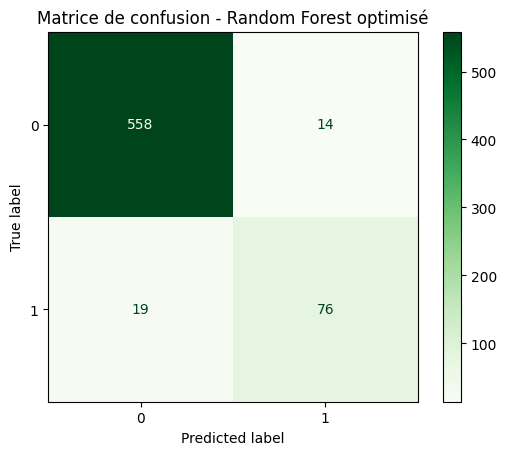

In [4]:
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Précision: {precision_score(y_test, y_pred):.3f}")
print(f"Rappel   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Greens')
plt.title("Matrice de confusion - Random Forest optimisé")
plt.show()


In [5]:
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring='f1')
print(f"F1-score en validation croisée (5 folds): {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")


F1-score en validation croisée (5 folds): 0.774 (+/- 0.039)


## 4. Importance des features

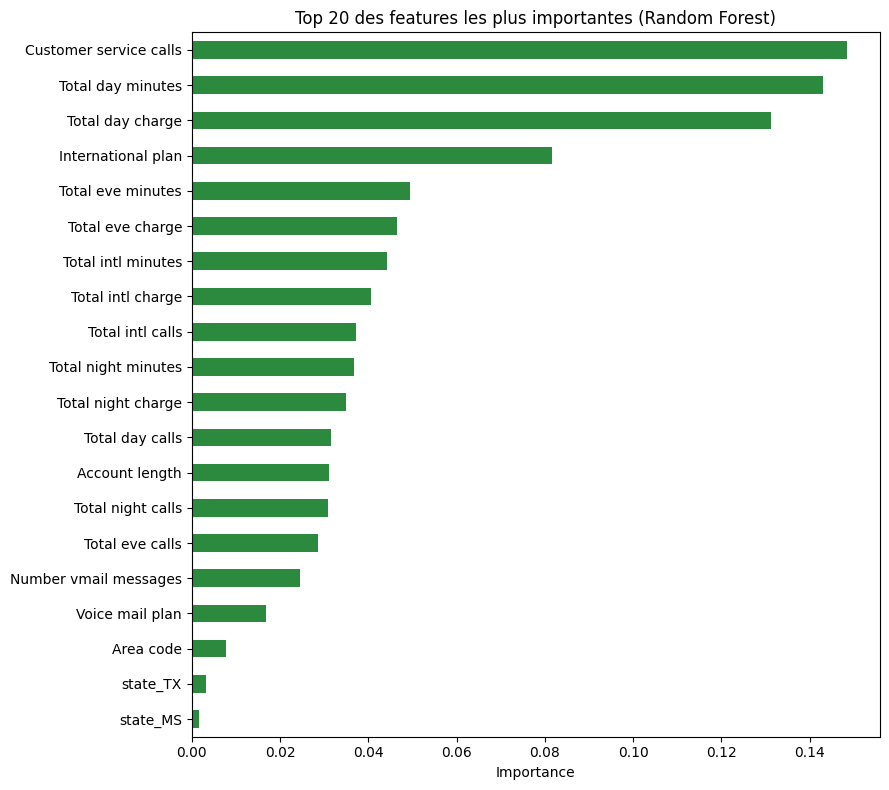

Customer service calls    0.148524
Total day minutes         0.143002
Total day charge          0.131331
International plan        0.081577
Total eve minutes         0.049437
Total eve charge          0.046412
Total intl minutes        0.044225
Total intl charge         0.040693
Total intl calls          0.037242
Total night minutes       0.036800
Total night charge        0.034854
Total day calls           0.031528
Account length            0.031008
Total night calls         0.030786
Total eve calls           0.028590
Number vmail messages     0.024475
Voice mail plan           0.016830
Area code                 0.007715
state_TX                  0.003275
state_MS                  0.001607
dtype: float64

In [6]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top20 = importances.head(20)

plt.figure(figsize=(9, 8))
top20.sort_values().plot(kind='barh', color='#2b8a3e')
plt.title("Top 20 des features les plus importantes (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

top20


## Conclusion

Après tuning, le Random Forest surpasse généralement la régression logistique en F1-score sur ce dataset grâce à sa capacité à capturer les interactions non-linéaires.
L'analyse d'importance des features confirme que le **nombre d'appels au service client**, la **présence d'un forfait international**, et les **minutes/charges de jour** sont les facteurs les plus déterminants du churn.
